In [1]:
import pandas as pd
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from sklearn.metrics import confusion_matrix
from multiprocessing import Pool
import math
from sklearn.preprocessing import StandardScaler
from collections import Counter
import numpy as np
from sklearn.cluster import HDBSCAN

In [2]:
PCA_rule_of_thumb=pd.read_csv('PCA_rule_of_thumb.csv')
PCA_kaiser=pd.read_csv('PCA_kaiser.csv')
PCA_parallel=pd.read_csv('PCA_parallel.csv')
UMAP_euclidean=pd.read_csv('UMAP_euclidean.csv')
UMAP_cosine=pd.read_csv('UMAP_cosine.csv')
UMAP_highdim=pd.read_csv('UMAP_highdim.csv')

In [6]:
# List of datasets (DataFrames) and their corresponding method names
datasets = [
    ("PCA_rule_of_thumb", PCA_rule_of_thumb),
    ("PCA_kaiser", PCA_kaiser),
    ("PCA_parallel", PCA_parallel),
    ("UMAP_euclidean", UMAP_euclidean),
    ("UMAP_cosine", UMAP_cosine),
    ("UMAP_highdim", UMAP_highdim)
]

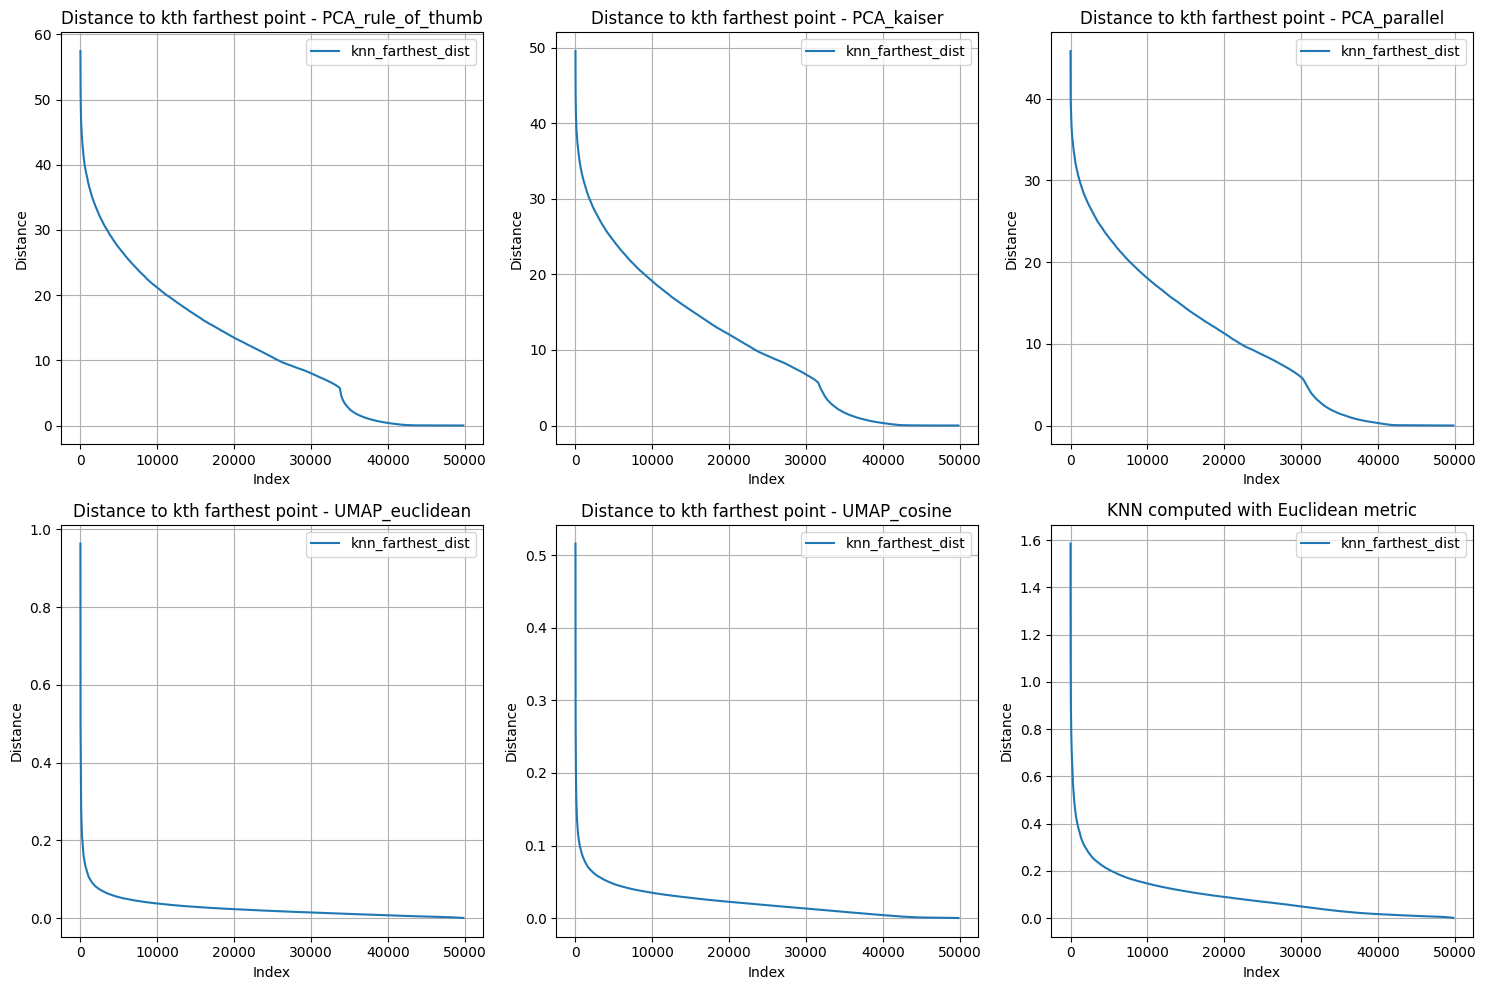

In [14]:
import matplotlib.pyplot as plt

k = 4  # Number of neighbors

# Assuming 'datasets' is a list of tuples with (method_name, df)
n_rows = 2  # Number of rows for the subplot grid
n_cols = 3  # Number of columns for the subplot grid

# Create subplots with the given number of rows and columns
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 10))

# Flatten the 2D array of axes to make indexing easier
axes = axes.flatten()

# Loop through datasets and plot on subplots
for i, (method_name, df) in enumerate(datasets):
    # Drop non-feature columns
    features = df.drop(columns=['user_uid', 'original_labels']).copy()

    # Fit Nearest Neighbors
    nbrs = NearestNeighbors(n_neighbors=k).fit(features)
    distances, _ = nbrs.kneighbors(features)

    # Store the farthest k-distance
    features['knn_farthest_dist'] = distances[:, -1]

    # Sort and plot for each dataset
    sorted_features = features.sort_values(by='knn_farthest_dist', ascending=False).reset_index()[['knn_farthest_dist']]
    ax = axes[i]  # Select the corresponding axis for the current plot
    sorted_features.plot(ax=ax)

    # Customize plot for each subplot
    ax.set_title(f"Distance to kth farthest point - {method_name}")
    ax.set_xlabel("Index")
    ax.set_ylabel("Distance")
    ax.grid(True)

# Adjust layout to make room for all subplots
plt.tight_layout()
plt.show()


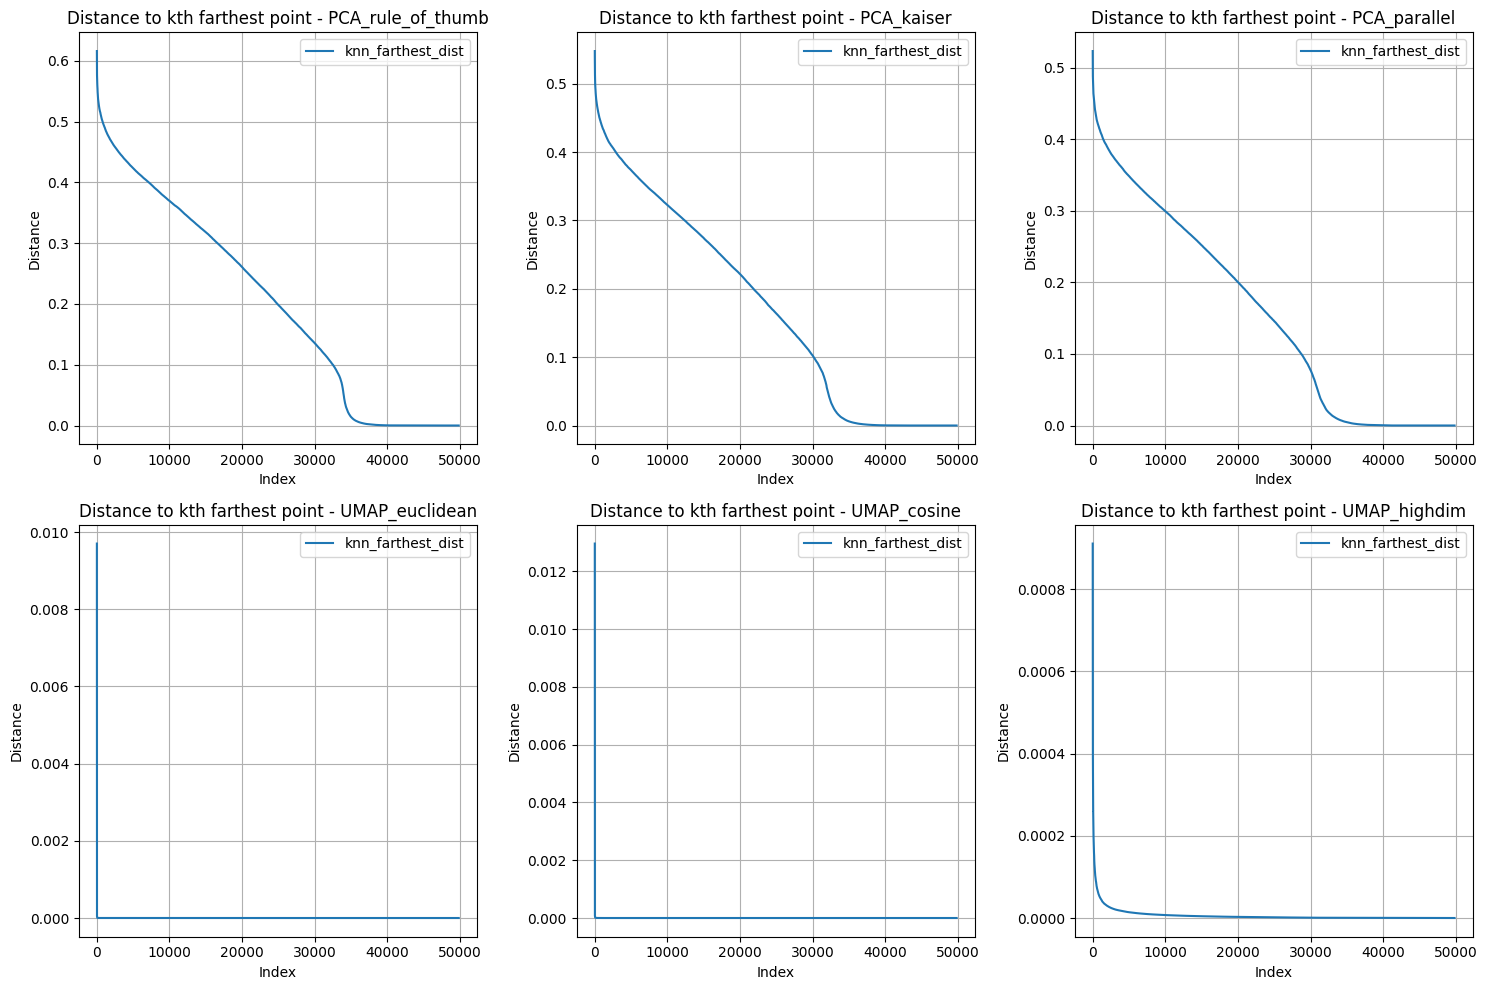

In [12]:
import matplotlib.pyplot as plt

k = 4  # Number of neighbors

# Assuming 'datasets' is a list of tuples with (method_name, df)
n_rows = 2  # Number of rows for the subplot grid
n_cols = 3  # Number of columns for the subplot grid

# Create subplots with the given number of rows and columns
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 10))

# Flatten the 2D array of axes to make indexing easier
axes = axes.flatten()

# Loop through datasets and plot on subplots
for i, (method_name, df) in enumerate(datasets):
    # Drop non-feature columns
    features = df.drop(columns=['user_uid', 'original_labels']).copy()

    # Fit Nearest Neighbors
    nbrs = NearestNeighbors(n_neighbors=k, metric='cosine').fit(features)
    distances, _ = nbrs.kneighbors(features)

    # Store the farthest k-distance
    features['knn_farthest_dist'] = distances[:, -1]

    # Sort and plot for each dataset
    sorted_features = features.sort_values(by='knn_farthest_dist', ascending=False).reset_index()[['knn_farthest_dist']]
    ax = axes[i]  # Select the corresponding axis for the current plot
    sorted_features.plot(ax=ax)

    # Customize plot for each subplot
    ax.set_title(f"Distance to kth farthest point - {method_name}")
    ax.set_xlabel("Index")
    ax.set_ylabel("Distance")
    ax.grid(True)

# Adjust layout to make room for all subplots
plt.tight_layout()
plt.show()
